# Modified Version of the Park Task

We set up 2 actions that will differ in *yaw angle* and *required force*. \
The actions are:
- Discrete action: pull left at +5˚, Continuous kinematics: force 3g (peak)
- Discrete action: pull right at -15˚, Continuous kinematics: force 12g (peak)

We produce beta distributions from the range 1 - 15g. One bundle peaks at 3g (pull left) and another at 12g (pull right). 
We encode these distributions as 512D bundle vectors. 

Therefore, we have:
- 2 action channels: pull left vs. pull right
- Continuous action parameter (force): 3g (peak for pull left) and 12g (peak for pull right)

We create a 2x2 action grid experimental design 
|Left| Right|
|---|---|
|L @ 3g | R @ 12g|
|L @ 12g| R @ 3g|
----

# Imports

In [82]:
# Add imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sspspace.sspspace.encoders import RandomSSPSpace

import nengo
from nengo.network import Network
from nengo import Node, Connection

# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility, ActionIterator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create Distributions & Bundles

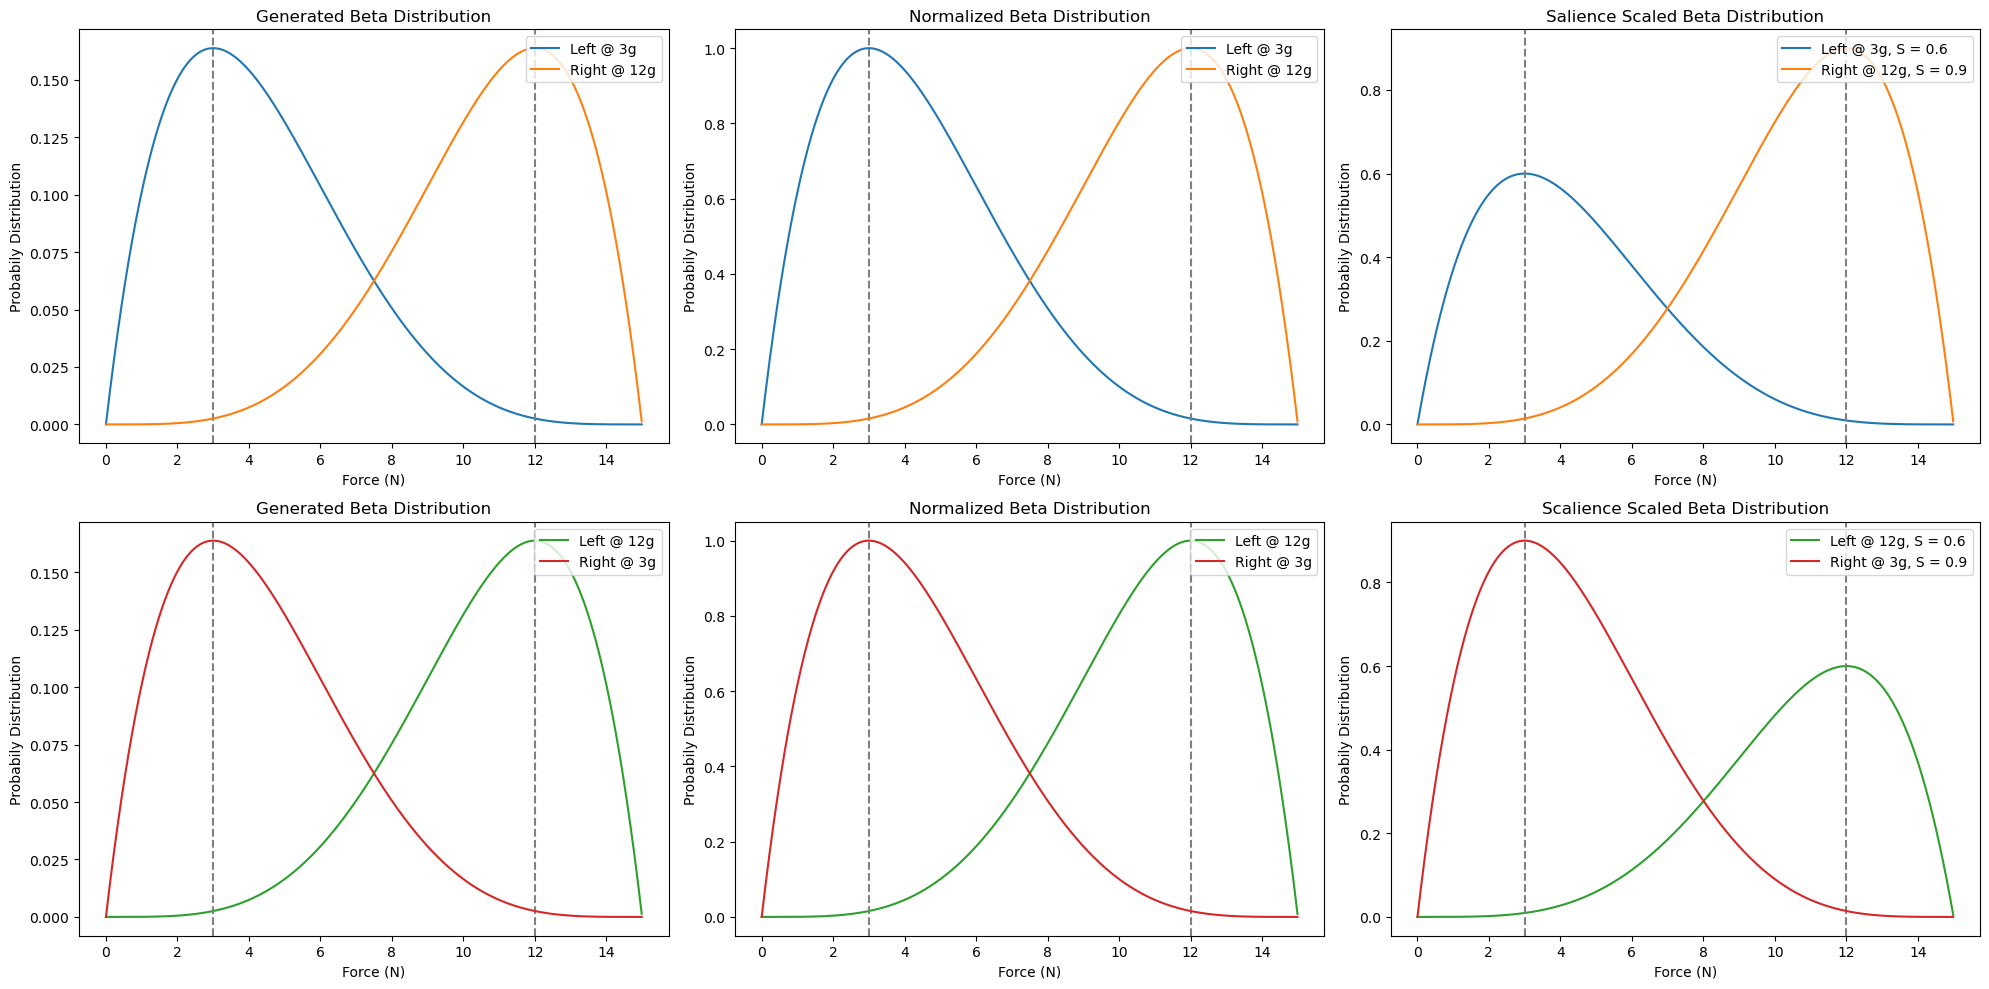

In [83]:
# ================================================
# 1. Define continuous force domain & SSP encoder
# ================================================
domain_force = np.arange(0, 15, 0.01).reshape(-1, 1) # Shape: (1500, 1)
ssp_dim = 512
n_actions_task = 4

# SSP encoder for scalar force values
ssp_encoder = RandomSSPSpace(
    domain_dim=1,
    ssp_dim=ssp_dim,
    rng=np.random.RandomState(0),
    length_scale=0.5
)
# Convert domain values to high-dimensional SSPs
domain_phis_task = ssp_encoder.encode(domain_force)  # shape: (1500, 512)
# print(domain_phis.shape)

# Place cell encoders for Nengo ensembles
low = 0
high = 15
width = high - low
places_task = np.arange(low, high, width/(domain_force.shape[0]))
dnf_encoders_task = np.asarray(ssp_encoder.encode(places_task.reshape(-1, 1))).squeeze() # Shape: (1500, 512)
# print(dnf_encoders.shape) # (512, 1500)

# ================================================
# 2. DNF Parameters
# ================================================
dnf_params_task = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions_task, 1500)], 
            'beta'            : 4,
    }


# ================================================
# 3. Generate two bundle vectors via Beta PDFs
#    Peaked at 3g and 12g respectively
# ================================================

# Beta shapes chosen so mode(a-1)/(a+b-2) matches desired peak/domain
a_s = [2, 5, 5, 2]  # for 3g (mode 0.2*15=3), for 12g (mode 0.8*15=12) 
b_s = [5, 2, 2, 5]
scale = 15
bundles_task = []
beta_pdfs_task = []

for a, b in zip(a_s, b_s):
    # Compute Beta PDF over the domain
    dist = beta.pdf(domain_force.squeeze(), a, b, scale=scale) # Shape: 1500
    beta_pdfs_task.append(dist)
    # Compute the SSP bundle via weighted sum over encoded domain
    bundle_vec = np.einsum('n,nd->d', dist, domain_phis_task) # (1500,) (1500, 512) = (512, )
    bundles_task.append(bundle_vec)

# ========================================
# 4. Salience values for actions
# ========================================
# Pull left (5˚, 3g) = 0.6 
# Pull right (-15˚, 12g) = 0.9
# Pull left (5˚, 12g) = 0.6
# Pull right (-15˚, 3g) = 0.9
salience_task = [0.6, 0.9, 0.6, 0.9] 

# ========================================
# 5. Plot the Beta distributions for each channel
# ========================================
colors = ['C0', 'C1', 'C2', 'C3']
actions = ['Left @ 3g', 'Right @ 12g', 'Left @ 12g', 'Right @ 3g']
peak = [3, 12, 12, 3]
normalized = Utility.to_normalize(beta_pdfs_task)
scaled = Utility.to_scale(salience_task, normalized)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Plot regular distribution 
for i in range(n_actions_task):
    if i >= 0 and i <2:
        axes[0, 0].plot(domain_force, beta_pdfs_task[i], label=f'{actions[i]}', color=f'{colors[i]}')
        axes[0,0].axvline(x = peak[i], color='grey', linestyle='--')
    else:
        axes[1, 0].plot(domain_force, beta_pdfs_task[i], label=f'{actions[i]}', color=f'{colors[i]}')
        axes[1,0].axvline(x = peak[i], color='grey', linestyle='--')
axes[0, 0].legend(loc='upper right')
axes[0, 0].set_title('Generated Beta Distribution')
axes[0, 0].set_ylabel('Probabily Distribution')
axes[0, 0].set_xlabel('Force (N)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].set_title('Generated Beta Distribution')
axes[1, 0].set_ylabel('Probabily Distribution')
axes[1, 0].set_xlabel('Force (N)')

# Plot normalized distribution

for i in range(n_actions_task):
    if i >= 0 and i <2:
        axes[0, 1].plot(domain_force, normalized[i], label=f'{actions[i]}', color=f'{colors[i]}')
        axes[0,1].axvline(x = peak[i], color='grey', linestyle='--')
    else:
        axes[1, 1].plot(domain_force, normalized[i], label=f'{actions[i]}', color=f'{colors[i]}')
        axes[1, 1].axvline(x = peak[i], color='grey', linestyle='--')
axes[0, 1].legend(loc='upper right')
axes[0, 1].set_title('Normalized Beta Distribution')
axes[0, 1].set_ylabel('Probabily Distribution')
axes[0, 1].set_xlabel('Force (N)')
axes[1, 1].legend(loc='upper right')
axes[1, 1].set_title('Normalized Beta Distribution')
axes[1, 1].set_ylabel('Probabily Distribution')
axes[1, 1].set_xlabel('Force (N)')

# Plot salience scaled distribution 
for i in range(n_actions_task):
    if i >= 0 and i <2:
        axes[0, 2].plot(domain_force, scaled[i], label=f'{actions[i]}, S = {salience_task[i]}', color=f'{colors[i]}')
        axes[0, 2].axvline(x = peak[i], color='grey', linestyle='--')
    else:
        axes[1, 2].plot(domain_force, scaled [i], label=f'{actions[i]}, S = {salience_task[i]}', color=f'{colors[i]}')
        axes[1, 2].axvline(x = peak[i], color='grey', linestyle='--')
axes[0, 2].legend(loc='upper right')
axes[0, 2].set_title('Salience Scaled Beta Distribution')
axes[0, 2].set_ylabel('Probabily Distribution')
axes[0, 2].set_xlabel('Force (N)')
axes[1, 2].legend(loc='upper right')
axes[1, 2].set_title('Scalience Scaled Beta Distribution')
axes[1, 2].set_ylabel('Probabily Distribution')
axes[1, 2].set_xlabel('Force (N)')

plt.tight_layout()
plt.savefig('./figures/modified_park/distribution.png')
plt.show()


# Build Basal Ganglia Model with Action Iterator

In [84]:
# =================================================
# 5. Assemble Nengo Model for Reach to Pull Task
# =================================================
# 4 action channels: L3, R12, L12, R3
n_actions_task = 4

# 3). DNF/BG Parameters
d1_weight = 1.0
d2_weight = 1.0
dopamine_level = 0.2

model = Network(label='Reach_to_Pull_BG')
input = Utility.to_normalize(beta_pdfs_task)
with model:

    action_iter = ActionIterator(n_actions=n_actions_task, normalized_vectors=input, domain_phis=domain_phis_task)
    action_node = Node(action_iter.step, size_out=n_actions_task * 512, label='action_salience')
    

    # input_bundle_nodes = []
    # for i in range(n_actions):
    #     cortical_bundle = nengo.Node(nengo.processes.PresentInput(inputs=[action_node[0:512]], presentation_time=4.0), 
    #                                  label =f'ssp_cortical_bundle_node_{i}')
    #     input_bundle_nodes.append(cortical_bundle)
    
    # Dopamine Node
    dopamine_node_task = nengo.Node(nengo.processes.PresentInput(inputs=[dopamine_level], presentation_time=4.0), 
                               label='dopamine_node')

    # # BG Model
    bg_model_task = BasalGanglia(n_actions=n_actions_task, dnf_parameters=dnf_params_task, encoders=dnf_encoders_task, dnf_neurons=1500)

    # # Output node
    out_node_task = Node(size_in = 512 * n_actions_task)

    # # Connections 
    Connection(dopamine_node_task, bg_model_task.dopamine, synapse=None)
    
    for i in range(n_actions_task):
        start = i * 512
        end = (i + 1) * 512
        Connection(action_node[start:end], bg_model_task.cortex_inputs[i], synapse=None)

    Connection(bg_model_task.bg_out, out_node_task, synapse=None)


    # Probes
    p_action_task = nengo.Probe(action_node, synapse=None)
    p_ins_task = []
    for i in range(n_actions_task):
        p_in_task = nengo.Probe(bg_model_task.cortex_inputs[i], 'output', synapse=None)
        p_ins_task.append(p_in_task)
    
    p_dnf_in_d1_task = nengo.Probe(bg_model_task.d1_dnf.g.neurons, 'input', synapse = None)
    p_dnf_neurons_d1_task= nengo.Probe(bg_model_task.d1_dnf.g.neurons, synapse=None)
    p_g_d1_task = nengo.Probe(bg_model_task.d1_dnf.g, synapse=None)

    p_dnf_in_d2_task = nengo.Probe(bg_model_task.d2_dnf.g.neurons, 'input', synapse = None)
    p_dnf_neurons_d2_task = nengo.Probe(bg_model_task.d2_dnf.g.neurons, synapse=None)
    p_g_d2_task = nengo.Probe(bg_model_task.d2_dnf.g, synapse=None)

    p_out_task = nengo.Probe(out_node_task, synapse = 0.02)

with nengo.Simulator(model) as sim:
    sim.run(4.0)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

# Plots

## Probes Processing

In [ ]:
time         = sim.trange()                           # (T,)
n_actions    = n_actions_task                         # 4
bundle_dim   = 512

# shape (T, n_actions, 512)
inp_bundles  = sim.data[p_action_task] # (4000, 2048)
out_bundles  = sim.data[p_out_task] # (4000, 2048)

# tells is the winning channel at each time step t 
inp_salience = np.argmax(inp_bundles, axis=1) // bundle_dim # for input, shape: (4000,) 
out_salience = np.argmax(out_bundles, axis=1) // bundle_dim # for output, shape: (4000,) 

# bundles : 512D vectors 
inp_bundles = sim.data[p_action_task] # shape: (4000, 2048)
out_bundles = sim.data[p_out_task] # shape: (4000, 2048)

# peak forces for output
peak_forces = np.zeros_like(out_salience, dtype=float) 

# Input to the d1 ensemble --> (1500, 1)
d1_input = sim.data[p_dnf_in_d1_task] # (4000, 6000)
d2_input = sim.data[p_dnf_in_d2_task]
# Neuron activities: 1500 neurons for the 1500 domain space
d1_neurons = sim.data[p_dnf_neurons_d1_task]# (4000, 6000)
d2_neurons = sim.data[p_dnf_neurons_d2_task] 

time_intervals = int(len(time)/1000)

matrix_in = np.zeros((time_intervals, n_actions_task, domain_force.shape[0])) # (time interval: 4, N_actions: 4, domain range: 1500)
matrix_out = np.zeros((time_intervals, n_actions_task, domain_force.shape[0])) # 

# These lists contain the concatenated version of the input and output distributions 
inp_data = [] # every element in this list is (6000, ) for (1500 * n_actions), length of this list is N actions
out_data = []

# Covert bundles --> distributions
for t in range(time_intervals):
    list_out = []
    list_in = []
    for n in range(n_actions_task):
        # grabbing the 998th timestep of each interval 
        segment_in = inp_bundles[(t + 1) * 1000 - 2][n * bundle_dim: (n + 1) * bundle_dim] # (512, 1)
        segment_out = out_bundles[(t + 1) * 1000 - 2][n * bundle_dim: (n + 1) * bundle_dim]
        # converts bundles to distributions
        matrix_in[t, n] = np.einsum('d,nd->n', segment_in, domain_phis_task) # (1500, 1)
        matrix_out[t, n] = np.einsum('d,nd->n', segment_out, domain_phis_task)
        list_in.append(matrix_in[t, n])
        list_out.append(matrix_out[t, n])
    inp_data.append(np.concatenate(list_in)) # (1500 * n_actions, 1)
    out_data.append(np.concatenate(list_out))


# Picks the winning channel and the peak force value 
for t_idx, ch in enumerate(out_salience):
    # raw bundle for chosen channel
    bundle = sim.data[p_out_task][t_idx][ch * bundle_dim: (ch + 1) * bundle_dim]
    distribution = np.einsum('d,nd->n', bundle, domain_phis_task)
    # softmax
    expo = np.exp(distribution - np.max(distribution))
    probs = expo / np.sum(expo)
    # find peak index
    idx = np.argmax(probs)
    # map index back to force value
    peak_forces[t_idx] = domain_force[idx]

/var/folders/p6/wzmppczn3f11rn2xkj_84k780000gn/T/ipykernel_11308/3391106.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  peak_forces[t_idx] = domain_force[idx]


## Selected Actions & Peak Forces

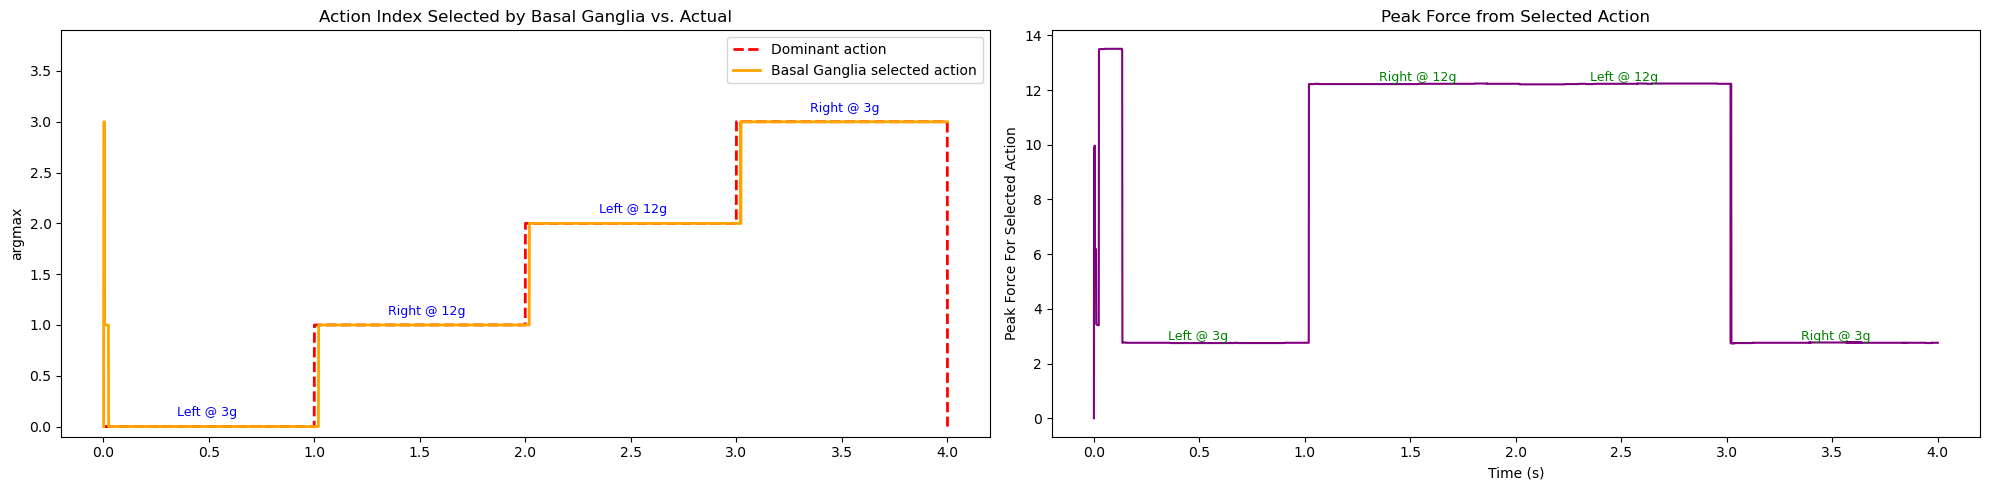

In [86]:
# find the winning channel 
# -----------------------------------------------
# 3. Pretty plot with labels every 1 s
# -----------------------------------------------
label_times   = np.arange(0, int(time[-1])) + 0.3
action_labels = ['Left @ 3g', 'Right @ 12g', 'Left @ 12g', 'Right @ 3g']

fix, axes = plt.subplots(1, 2, figsize=(20, 5))

# --- (a) INPUT & OUTPUT ---
axes[0].plot(time, inp_salience, lw=2, label='Dominant action', linestyle = '--', color='red')
axes[0].plot(time, out_salience, lw=2, label = 'Basal Ganglia selected action', color = 'orange')
axes[0].set_ylim(-0.1, n_actions_task-0.1)
axes[0].set_ylabel('argmax')
axes[0].legend()
axes[0].set_title('Action Index Selected by Basal Ganglia vs. Actual')

for t in label_times:
    idx = np.argmin(np.abs(time - t))
    val = inp_salience[idx]
    axes[0].text(t + 0.05, val + 0.1, action_labels[val],
             fontsize=9, color='blue')

axes[1].plot(time, peak_forces, color ='purple')
axes[1].set_title('Peak Force from Selected Action')
axes[1].set_xlabel('Time (s)'); 
axes[1].set_ylabel('Peak Force For Selected Action')
# Add annotations
for t in label_times:
    idx = np.argmin(np.abs(time - t))
    val = peak_forces.tolist()[idx]
    axes[1].text(t + 0.05, val + 0.1, f"{action_labels[int(idx/1000)]}", fontsize=9, color='green')

plt.tight_layout()
plt.savefig('./figures/modified_park/select_action.png')
plt.show()

## Input Vs. Orginal Beta Distributions

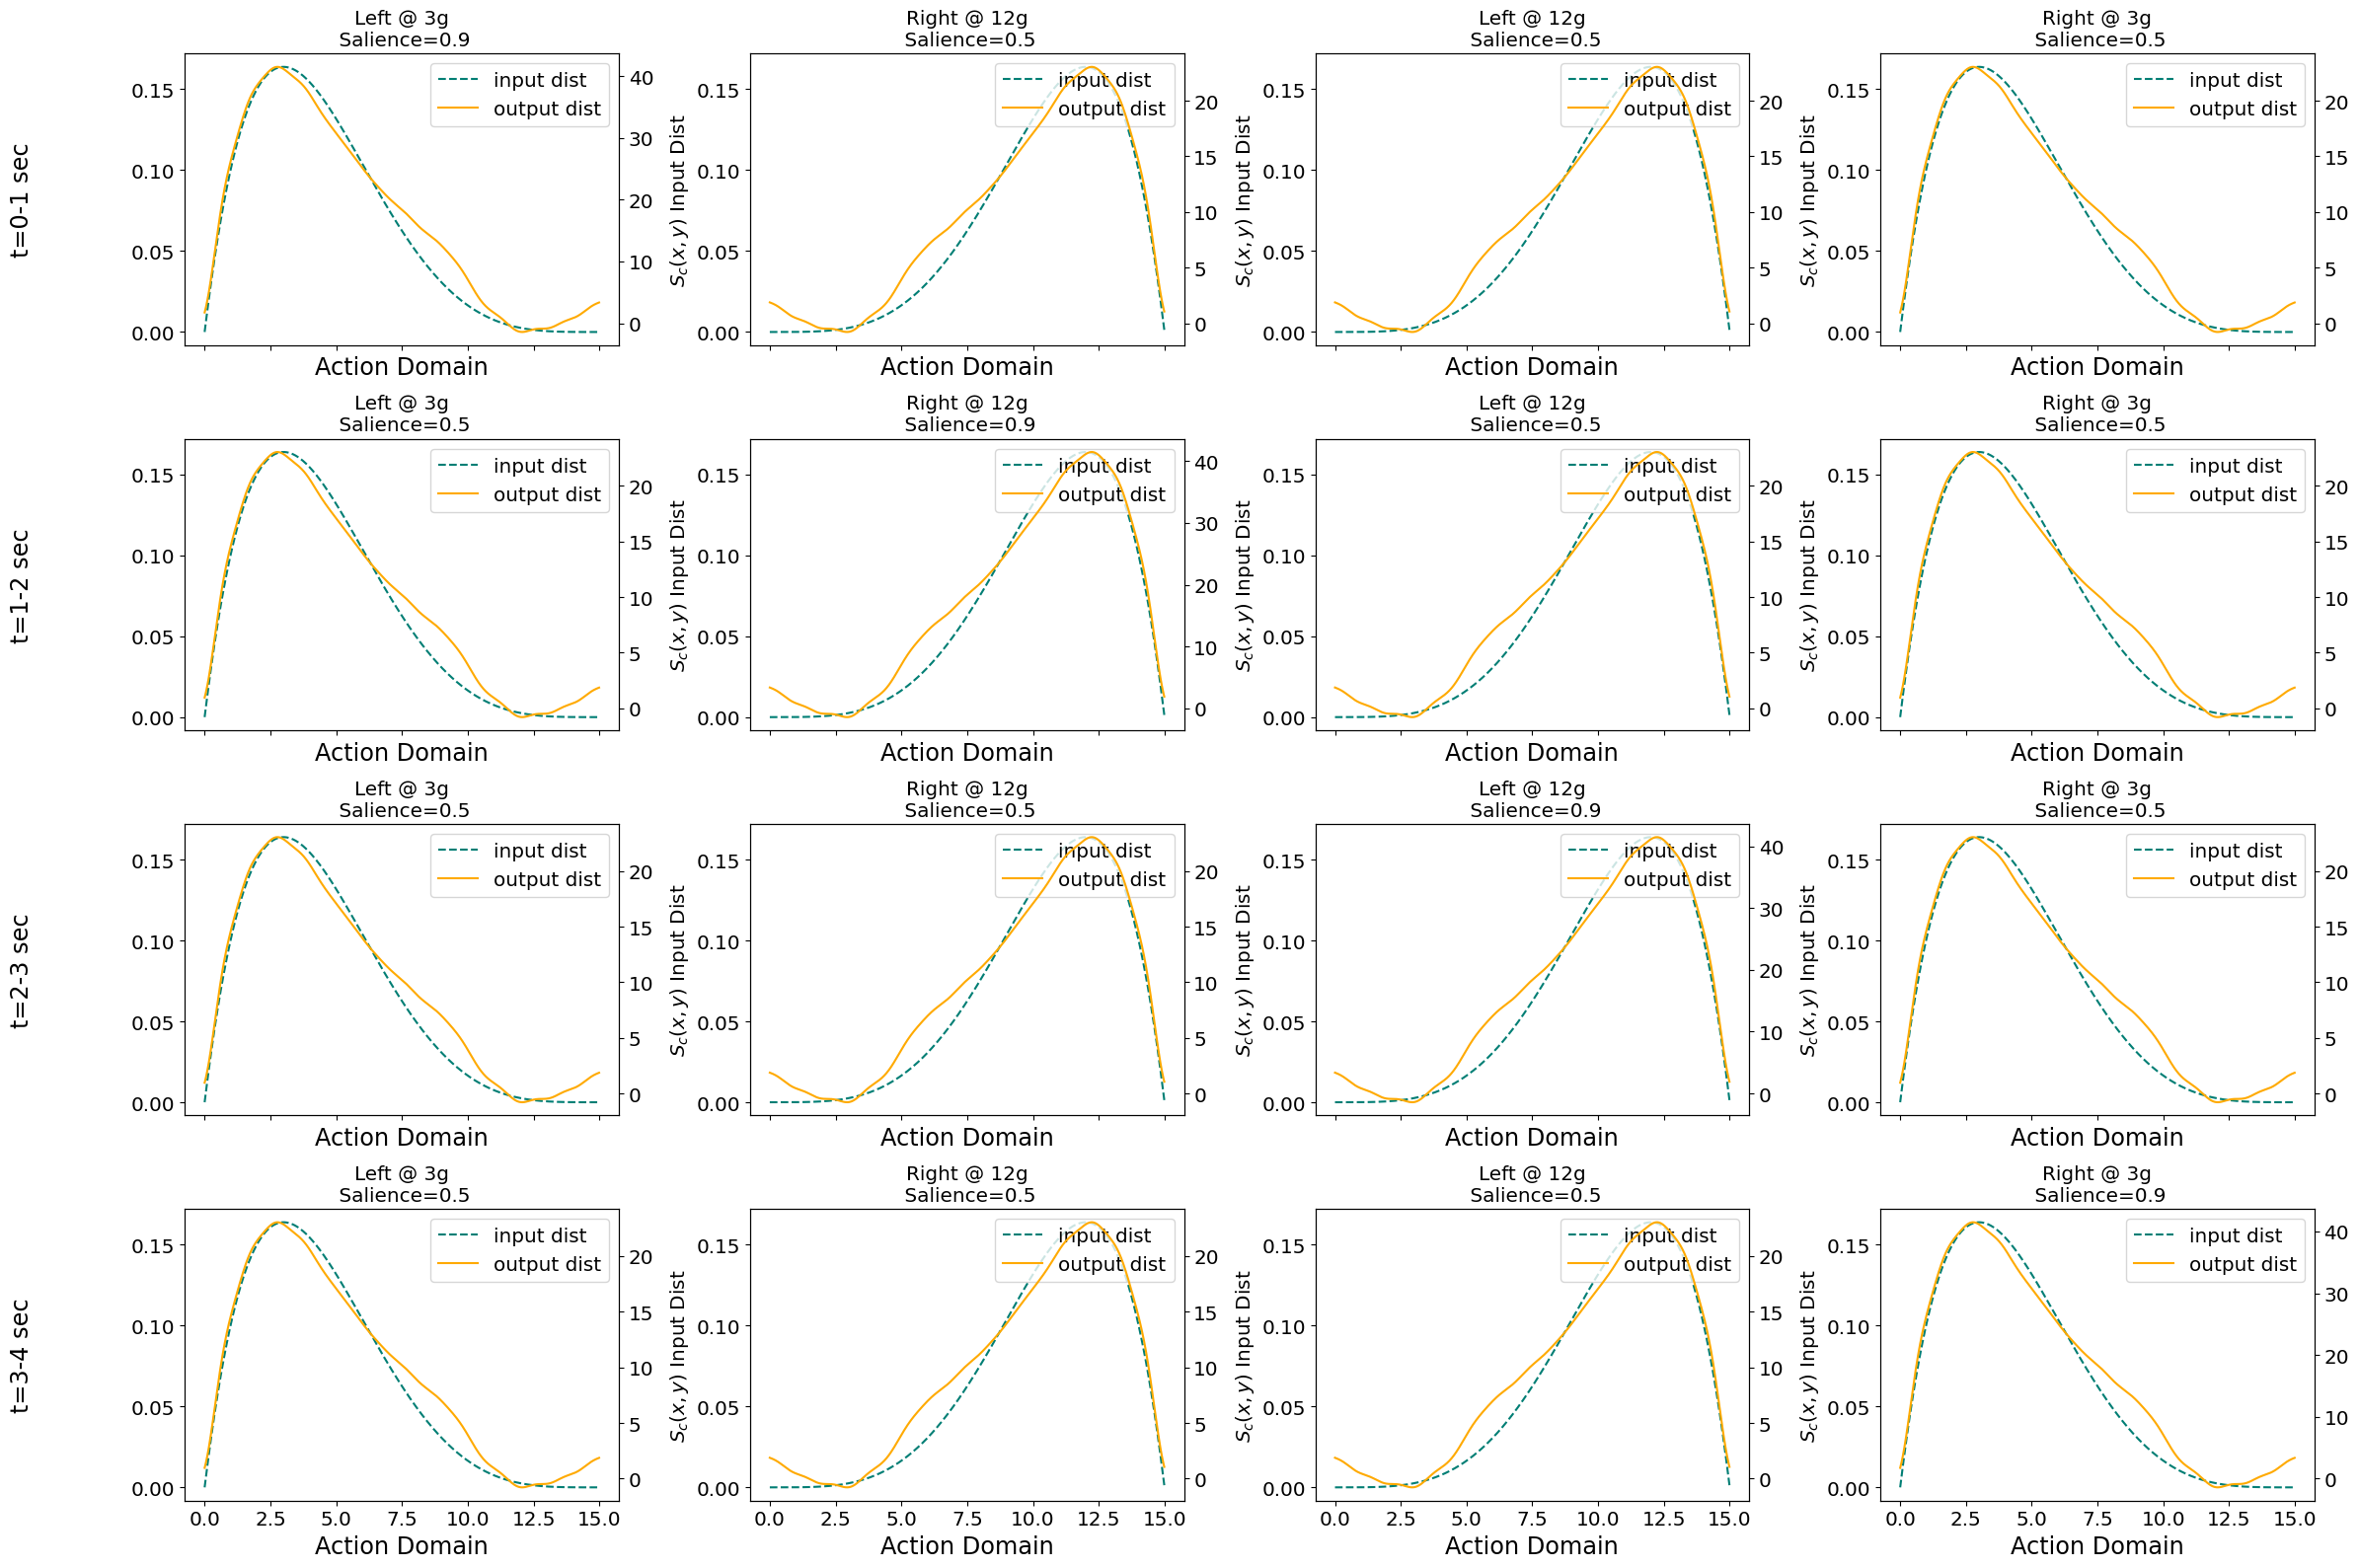

In [87]:
action_labels = ['Left @ 3g', 'Right @ 12g', 'Left @ 12g', 'Right @ 3g']
row_titles = []
salience_plot = np.ones((time_intervals, n_actions)) * 0.5
for i in range(time_intervals):
    salience_plot[i, i] = 0.9
    row_titles.append(f't={i}-{i+1} sec')
# Plot figures 
# Create a t x n plots side by side, where the row represents 1 sec time interval
fig, axes = plt.subplots(time_intervals, n_actions_task, figsize=(6 * n_actions_task, 4 * time_intervals), sharex=True)

# If you only have one action, axes will not be a list
if n_actions == 1:
    axes = [axes]

for t in range(time_intervals):
    for n in range(n_actions_task):
        ax = axes[t, n]
        # Primary y-axis: input distribution
        ax.plot(domain_force.squeeze(), beta_pdfs_task[n],
                ls='--', color="#007e74", label="input dist")
        ax.set_xlabel("Action Domain", fontsize="xx-large")
        ax.set_ylabel("$S_c(x,y)$ Input Dist", fontsize="x-large")
        ax.tick_params(axis='x', labelsize='x-large')
        ax.tick_params(axis='y', labelsize='x-large')

        # Secondary y-axis: output distribution
        ax2 = ax.twinx()
        ax2.plot(domain_force.squeeze(), matrix_in[t, n],
                 ls='-', color="#ffaa00", label="output dist")
        ax2.tick_params(axis='y', labelsize='x-large')

        # Combined legend
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize='x-large')

        ax.set_title(f'{action_labels[n]}\n Salience={salience_plot[t, n]}', fontsize='x-large')

    axes[t, 0].set_ylabel(row_titles[t], fontsize='xx-large', labelpad=80, rotation=90, va='center')
plt.tight_layout()
plt.savefig('./figures/modified_park/input.png')
plt.show()


# DNF - D1 & D2 

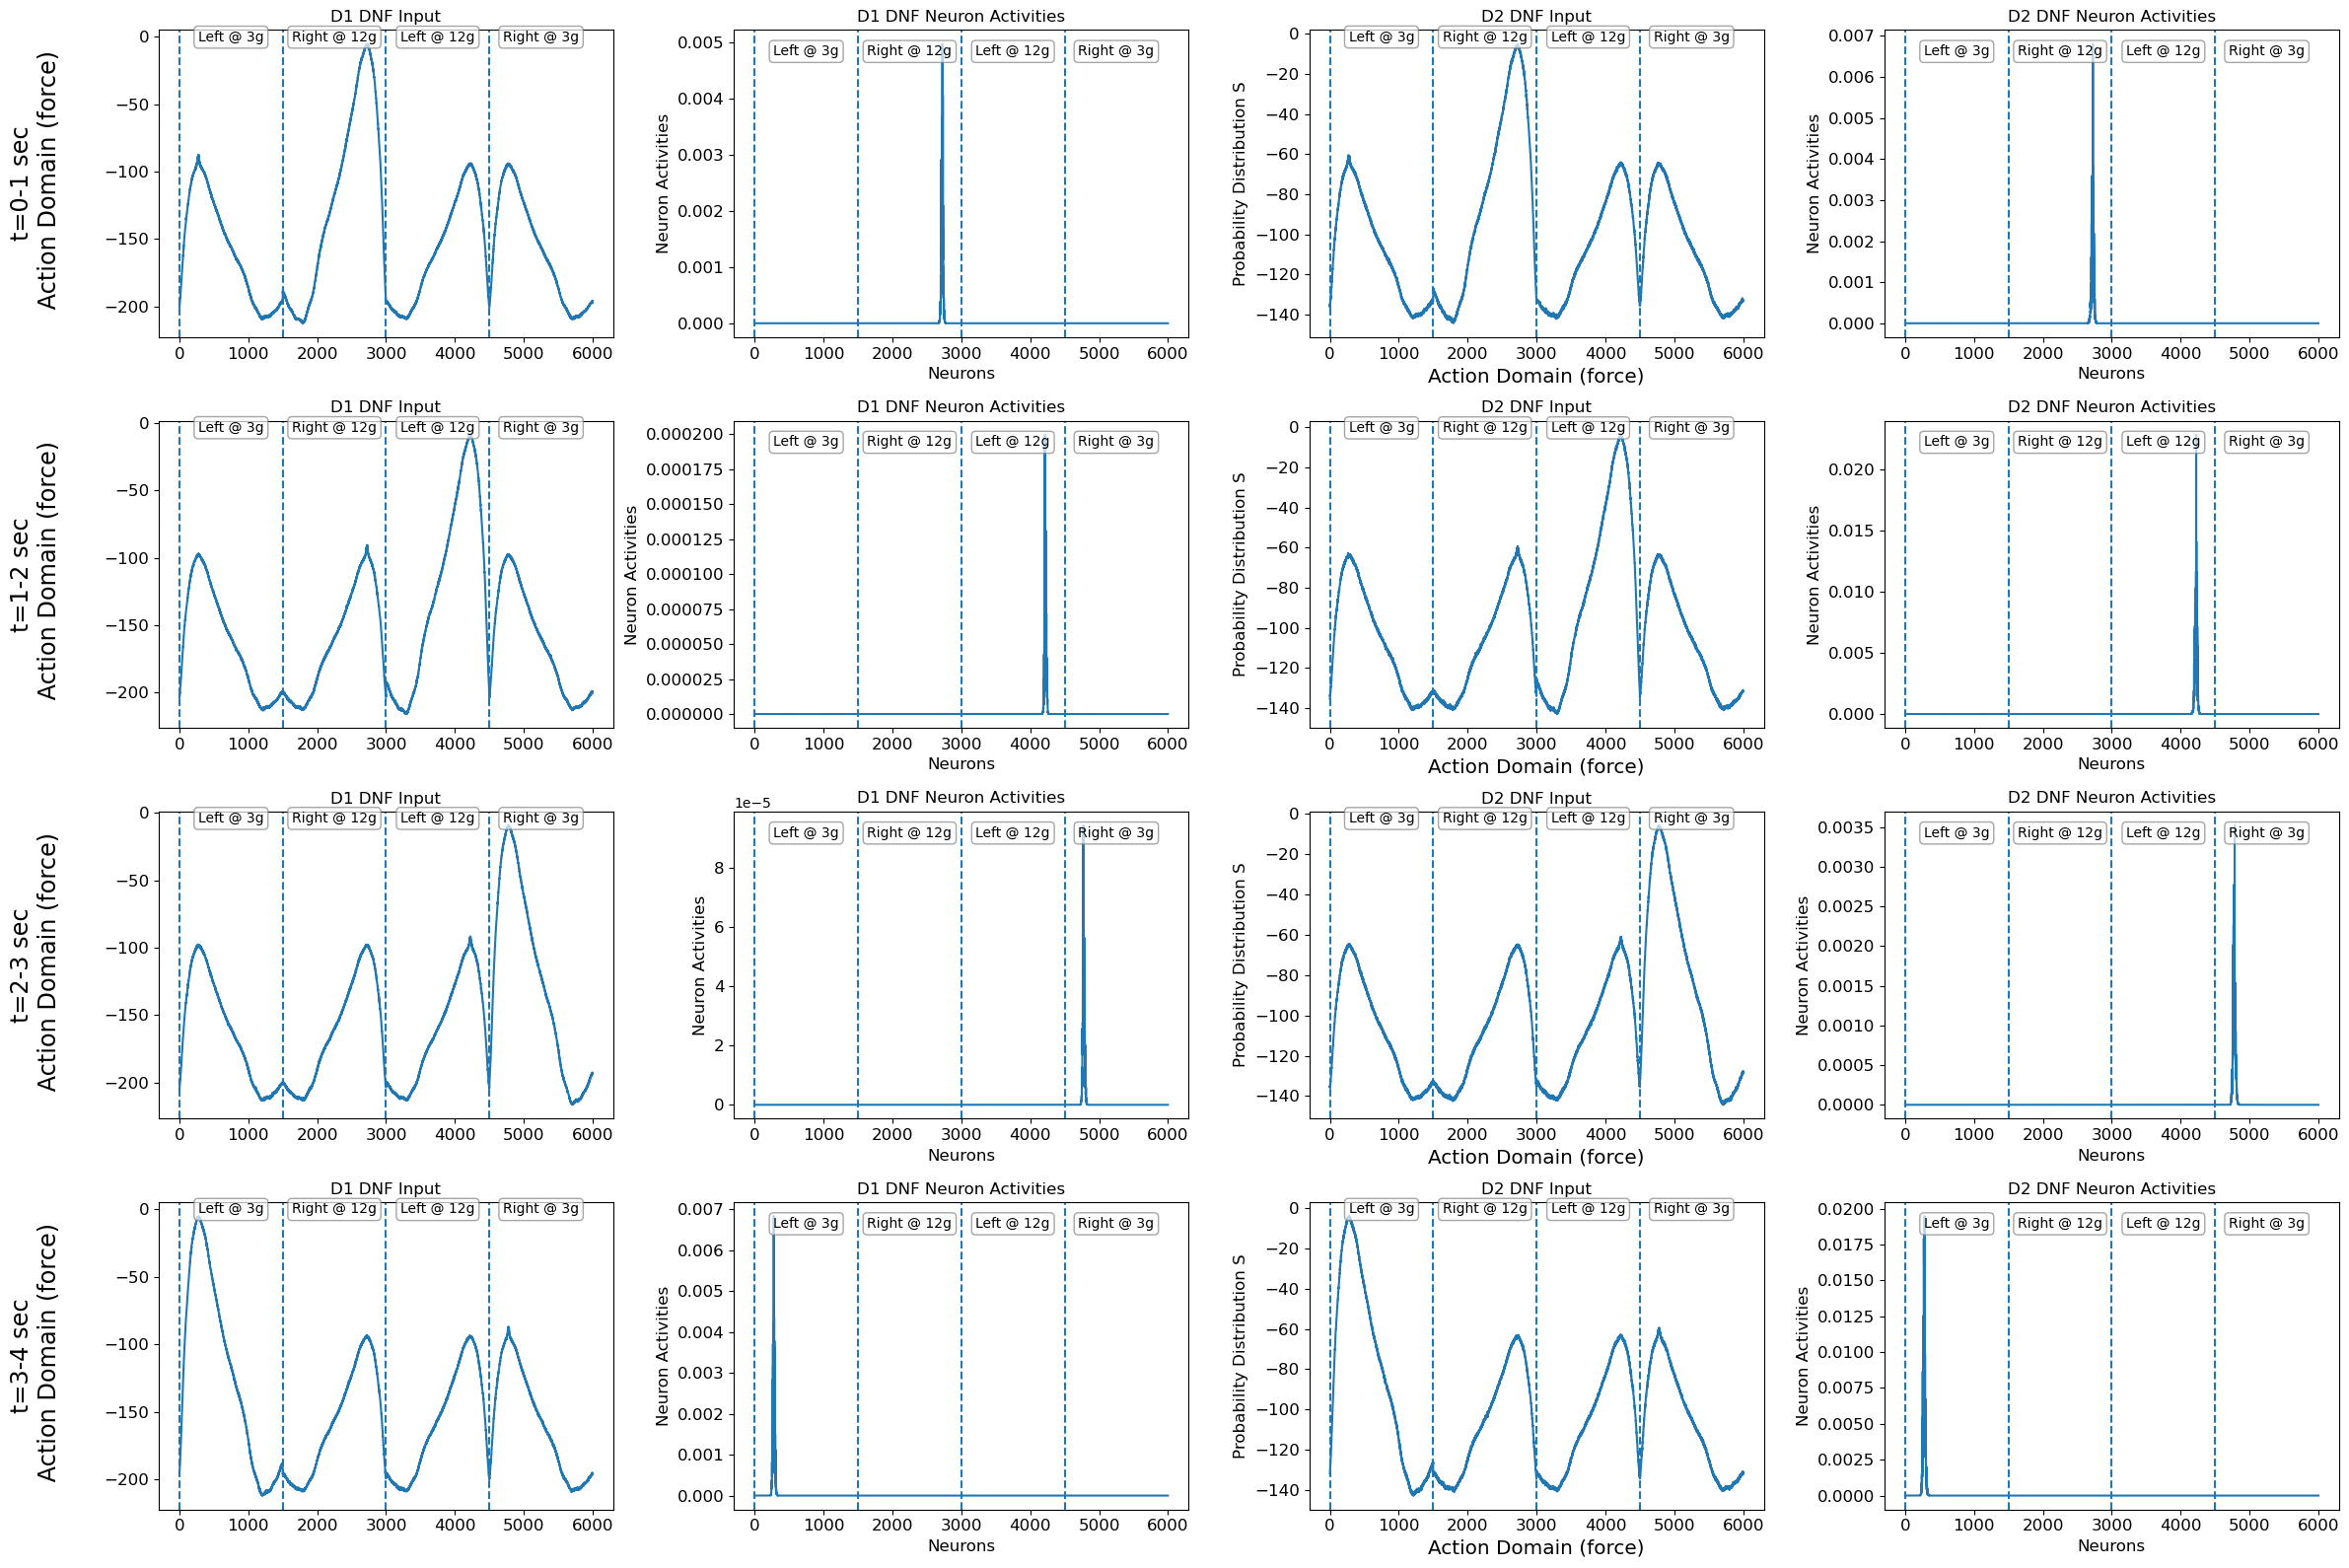

In [88]:
fig, axes = plt.subplots(time_intervals, 4, figsize=(6 * n_actions_task, 4 * time_intervals))
plt.subplots_adjust(wspace=0.8, hspace=0.8)

# If you only have one action, axes will not be a list
if n_actions == 1:
    axes = [axes]

for t in range(time_intervals):
    time_index = (t + 1) * 1000 - 1
    # Plot D1 Input 
    axes[t, 0].plot(np.arange(0, 6000), d1_input[time_index])
    axes[t, 0].set_ylabel('Probability Distribution S', fontsize='large')
    axes[t, 0].set_ylabel(row_titles[t] + '\n Action Domain (force)', fontsize='xx-large', rotation=90, labelpad=50, va='center')
    axes[t, 0].tick_params(axis='x', labelsize='large')
    axes[t, 0].tick_params(axis='y', labelsize='large')
    axes[t, 0].set_title(f'D1 DNF Input')
    # Plot D1 Neuron Activities
    axes[t, 1].plot(d1_neurons[time_index])
    axes[t, 1].set_ylabel('Neuron Activities', fontsize='large')
    axes[t, 1].set_xlabel('Neurons', fontsize='large')
    axes[t, 1].tick_params(axis='x', labelsize='large')
    axes[t, 1].tick_params(axis='y', labelsize='large')
    axes[t, 1].set_title(f'D1 DNF Neuron Activities')
    # Plot D2 Input 
    axes[t, 2].plot(np.arange(0, 6000), d2_input[time_index])
    axes[t, 2].set_ylabel('Probability Distribution S', fontsize='large')
    axes[t, 2].set_xlabel('Action Domain (force)', fontsize='x-large')
    axes[t, 2].tick_params(axis='x', labelsize='large')
    axes[t, 2].tick_params(axis='y', labelsize='large')
    axes[t, 2].set_title(f'D2 DNF Input')
    # Plot D2 Neuron Activities
    axes[t, 3].plot(d2_neurons[time_index])
    axes[t, 3].set_ylabel('Neuron Activities', fontsize='large')
    axes[t, 3].set_xlabel('Neurons', fontsize='large')
    axes[t, 3].tick_params(axis='x', labelsize='large')
    axes[t, 3].tick_params(axis='y', labelsize='large')
    axes[t, 3].set_title(f'D2 DNF Neuron Activities')

for i in range(time_intervals):
    for p in range(4):
        for n in range(n_actions_task):
            xpos = n * domain_force.shape[0]
            axes[i, p].axvline(xpos, linestyle='--')
            # Compute the center between this and the next section
            if n < n_actions_task - 1:
                next_xpos = (n + 1) * domain_force.shape[0]
                x_text = (xpos + next_xpos) / 2
            else:
                # For the last section, center in the last segment
                x_text = xpos + domain_force.shape[0] / 2
            # Place text near the top of the plot
            y_text = axes[i, p].get_ylim()[1] * 0.95  # 95% up the y-axis
            axes[i, p].text(
                x_text, y_text,
                f"{action_labels[n]}",
                ha='center', va='top',
                fontsize='medium',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
            )

   
plt.tight_layout()
plt.savefig('./figures/modified_park/dnf.png')
plt.show()

    

## Input vs. Output Distributions

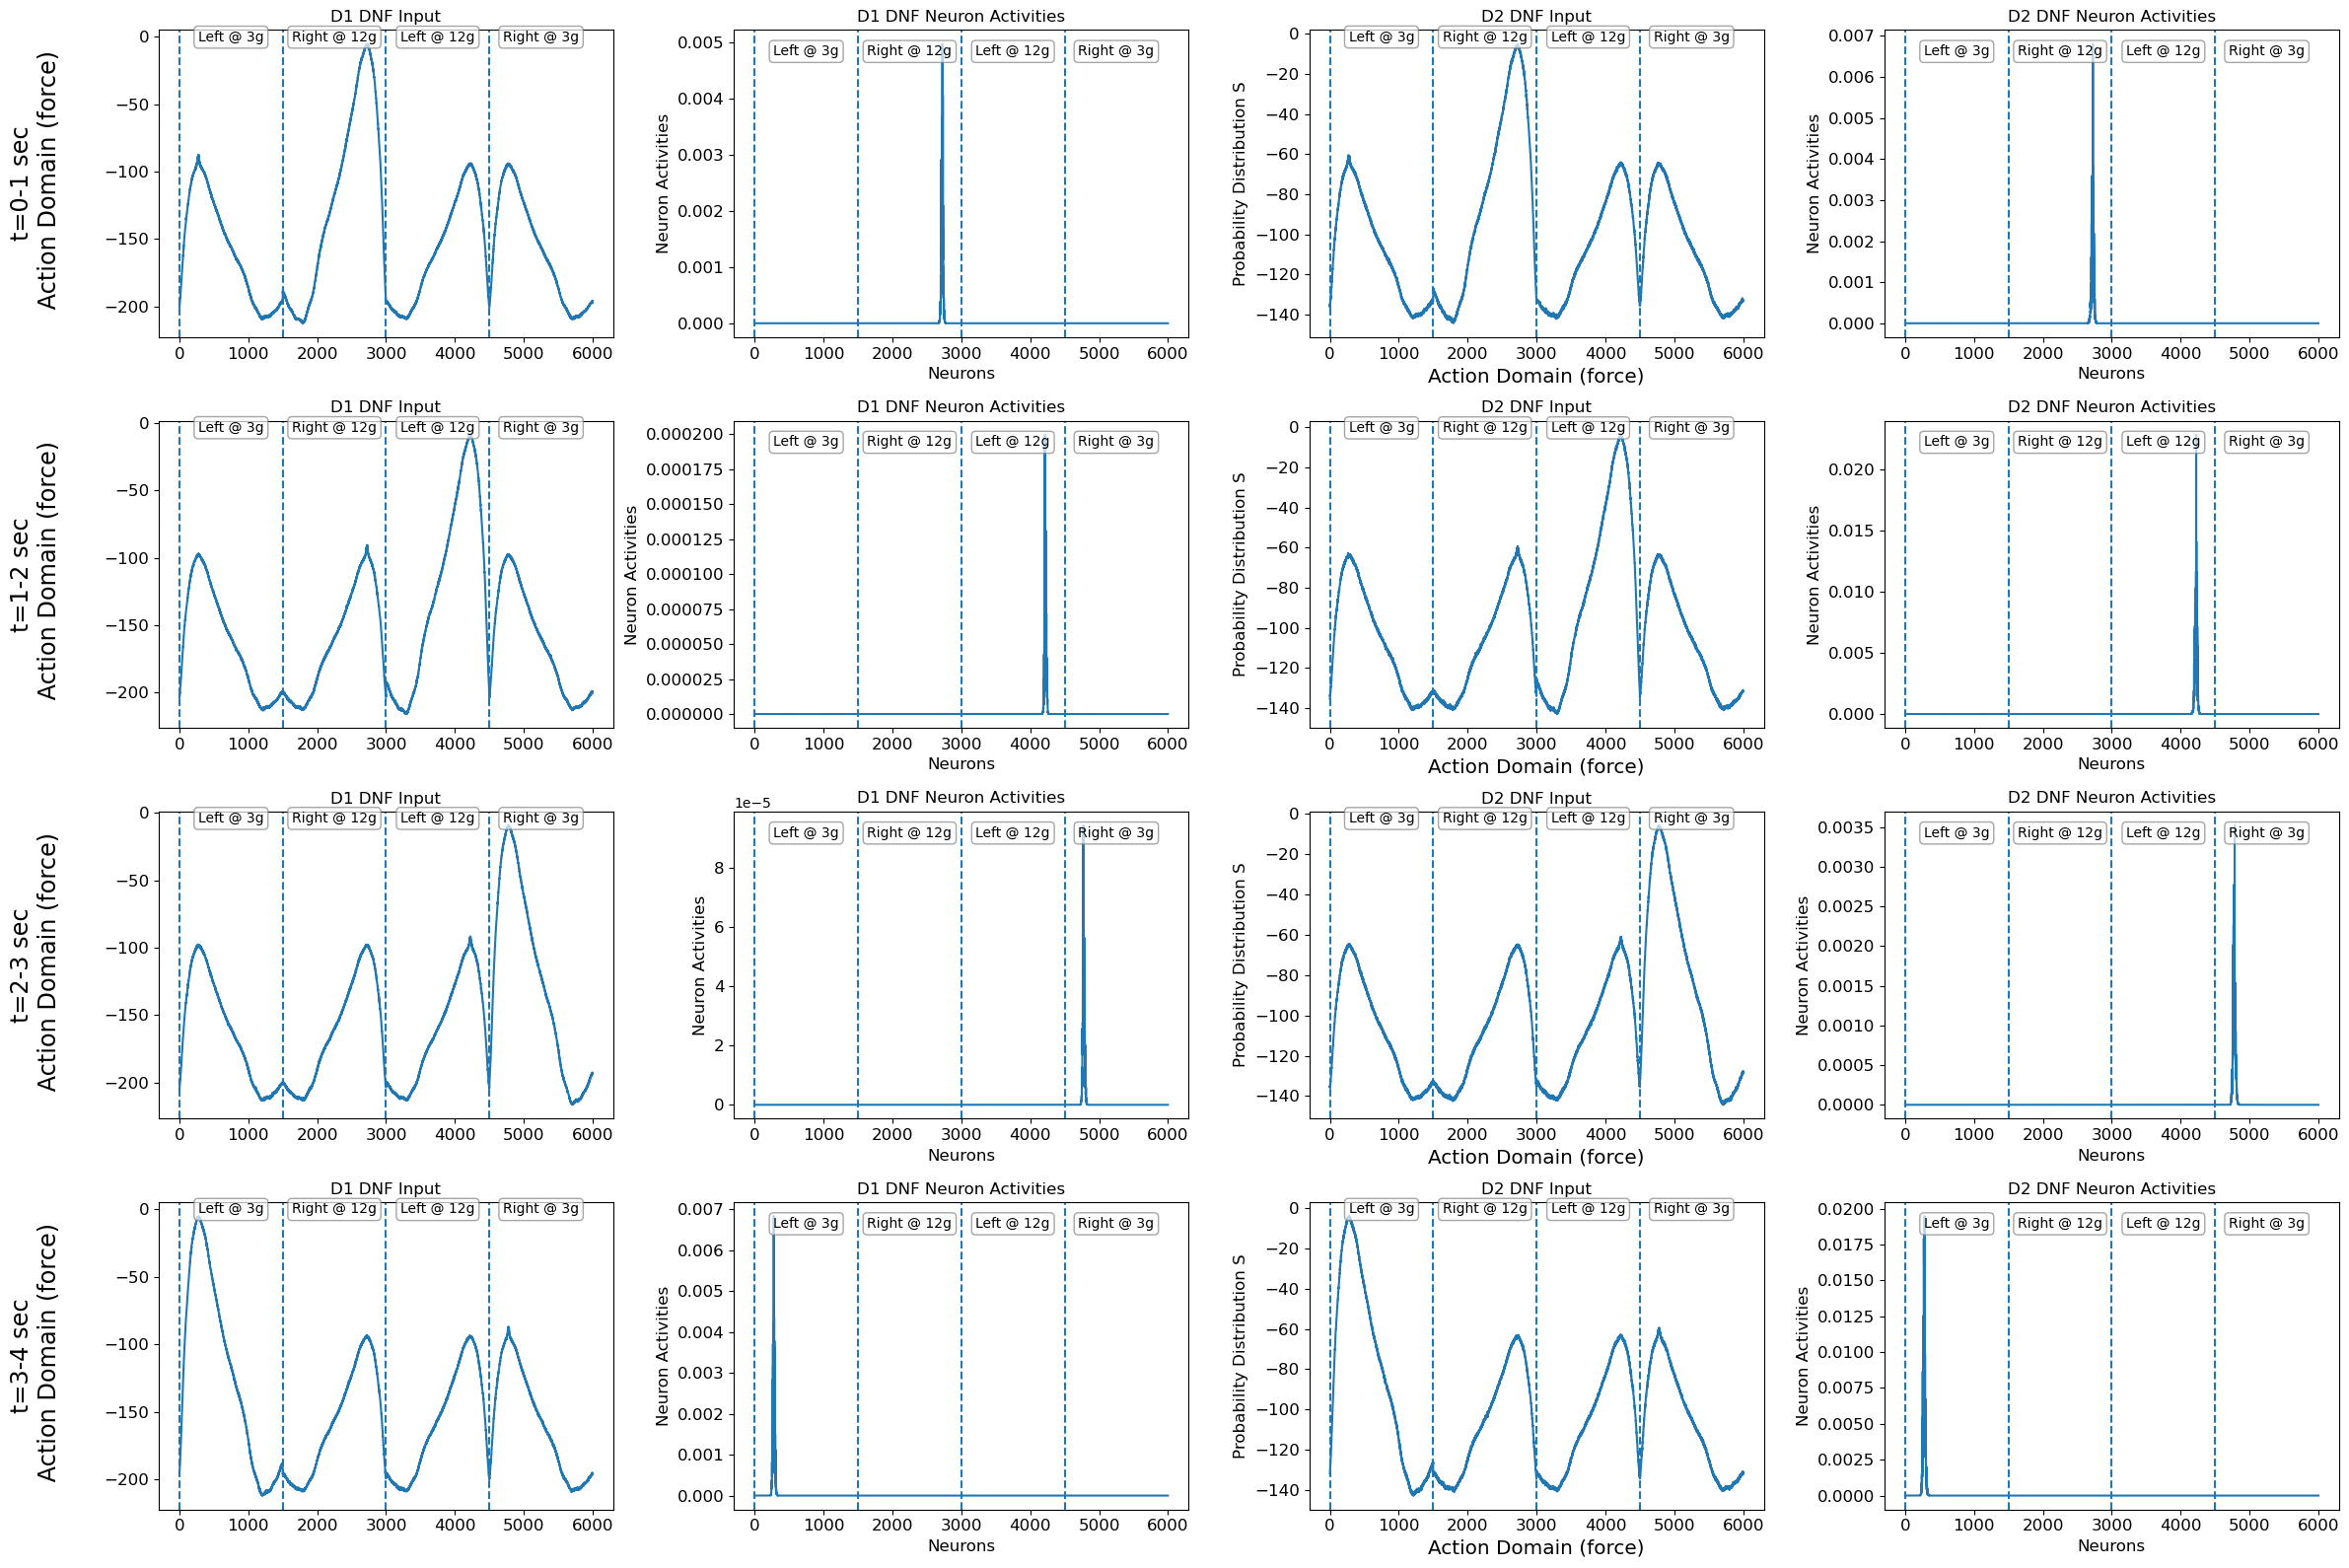

In [89]:
fig, axes = plt.subplots(time_intervals, 4, figsize=(6 * n_actions_task, 4 * time_intervals))
plt.subplots_adjust(wspace=0.8, hspace=0.8)

# If you only have one action, axes will not be a list
if n_actions == 1:
    axes = [axes]

for t in range(time_intervals):
    time_index = (t + 1) * 1000 - 1
    # Plot D1 Input 
    axes[t, 0].plot(np.arange(0, 6000), d1_input[time_index])
    axes[t, 0].set_ylabel('Probability Distribution S', fontsize='large')
    axes[t, 0].set_ylabel(row_titles[t] + '\n Action Domain (force)', fontsize='xx-large', rotation=90, labelpad=50, va='center')
    axes[t, 0].tick_params(axis='x', labelsize='large')
    axes[t, 0].tick_params(axis='y', labelsize='large')
    axes[t, 0].set_title(f'D1 DNF Input')
    # Plot D1 Neuron Activities
    axes[t, 1].plot(d1_neurons[time_index])
    axes[t, 1].set_ylabel('Neuron Activities', fontsize='large')
    axes[t, 1].set_xlabel('Neurons', fontsize='large')
    axes[t, 1].tick_params(axis='x', labelsize='large')
    axes[t, 1].tick_params(axis='y', labelsize='large')
    axes[t, 1].set_title(f'D1 DNF Neuron Activities')
    # Plot D2 Input 
    axes[t, 2].plot(np.arange(0, 6000), d2_input[time_index])
    axes[t, 2].set_ylabel('Probability Distribution S', fontsize='large')
    axes[t, 2].set_xlabel('Action Domain (force)', fontsize='x-large')
    axes[t, 2].tick_params(axis='x', labelsize='large')
    axes[t, 2].tick_params(axis='y', labelsize='large')
    axes[t, 2].set_title(f'D2 DNF Input')
    # Plot D2 Neuron Activities
    axes[t, 3].plot(d2_neurons[time_index])
    axes[t, 3].set_ylabel('Neuron Activities', fontsize='large')
    axes[t, 3].set_xlabel('Neurons', fontsize='large')
    axes[t, 3].tick_params(axis='x', labelsize='large')
    axes[t, 3].tick_params(axis='y', labelsize='large')
    axes[t, 3].set_title(f'D2 DNF Neuron Activities')

for i in range(time_intervals):
    for p in range(4):
        for n in range(n_actions_task):
            xpos = n * domain_force.shape[0]
            axes[i, p].axvline(xpos, linestyle='--')
            # Compute the center between this and the next section
            if n < n_actions_task - 1:
                next_xpos = (n + 1) * domain_force.shape[0]
                x_text = (xpos + next_xpos) / 2
            else:
                # For the last section, center in the last segment
                x_text = xpos + domain_force.shape[0] / 2
            # Place text near the top of the plot
            y_text = axes[i, p].get_ylim()[1] * 0.95  # 95% up the y-axis
            axes[i, p].text(
                x_text, y_text,
                f"{action_labels[n]}",
                ha='center', va='top',
                fontsize='medium',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
            )

   
plt.tight_layout()
plt.savefig('./figures/modified_park/output.png')
plt.show()


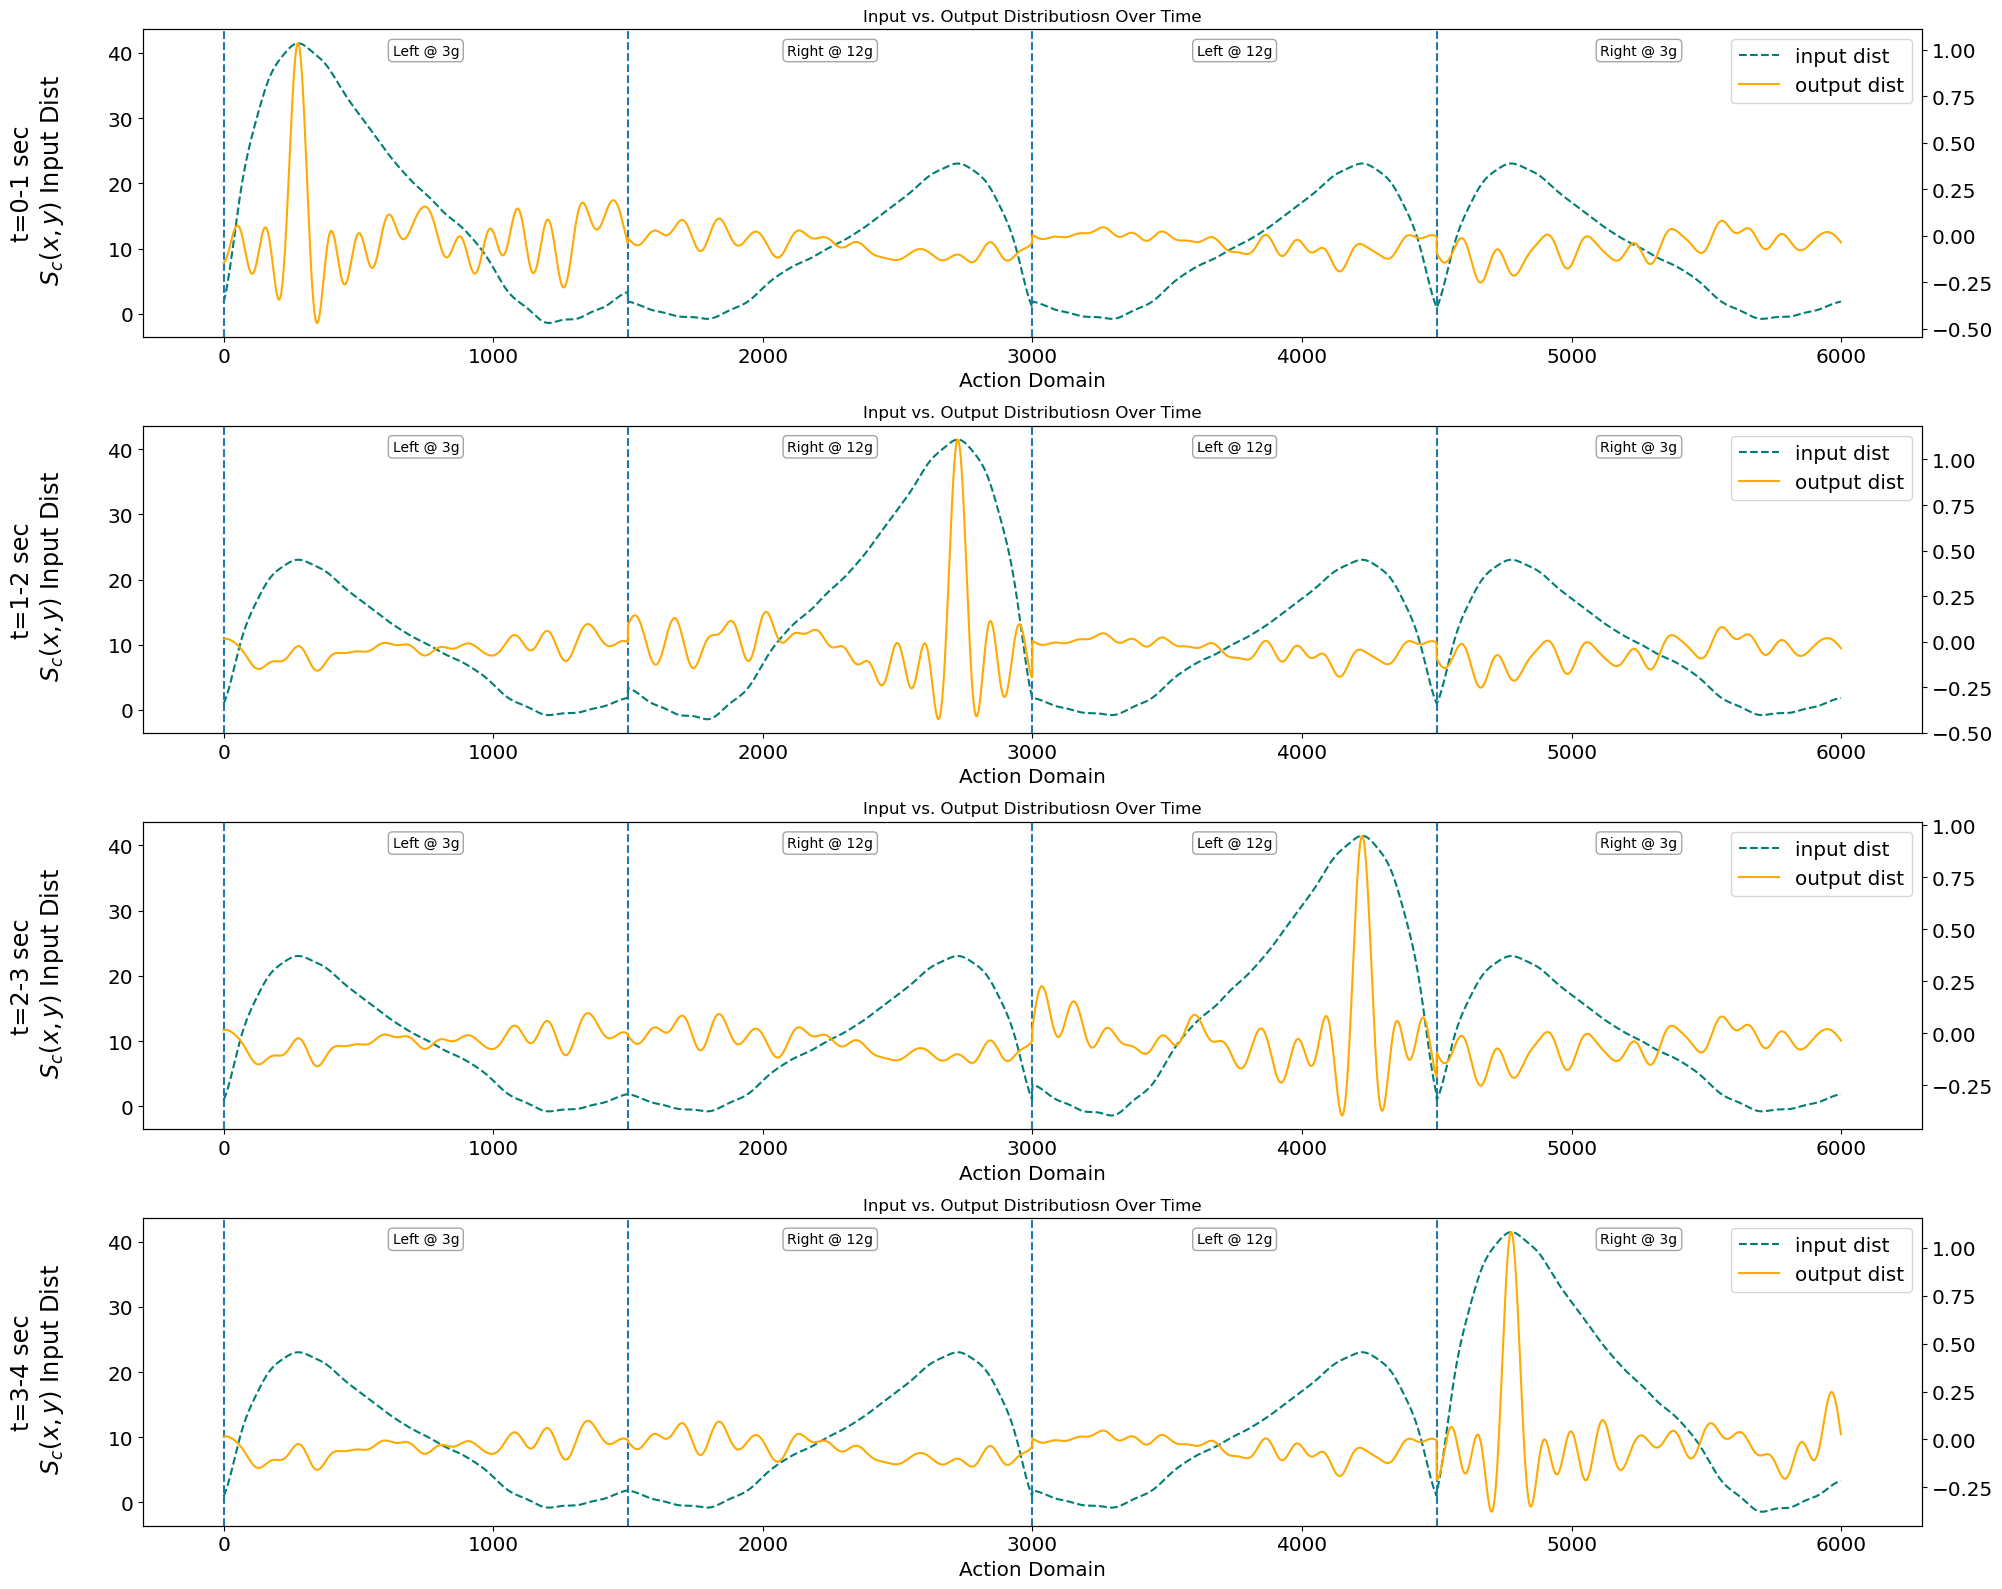

In [90]:
fig, axes = plt.subplots(
    time_intervals, 1,
    figsize=(5 * n_actions, 4 * time_intervals),
)
plt.subplots_adjust(hspace=0.8)

# If you only have one action, axes will not be a list
if n_actions == 1:
    axes = [axes]


for i, ax in enumerate(axes):
    # primary y-axis: input distribution
    ax.plot(inp_data[i],
            ls='--', color="#007e74",
            label="input dist")
    ax.set_xlabel("Action Domain", fontsize="x-large")
    ax.set_ylabel(row_titles[i] + '\n $S_c(x,y)$ Input Dist', fontsize='xx-large', rotation=90, labelpad=50, va='center')
    ax.tick_params(axis='x', labelsize='x-large')
    ax.tick_params(axis='y', labelsize='x-large')

    # secondary y-axis: output distribution
    ax2 = ax.twinx()
    ax2.plot( out_data[i],
             ls='-', color="#ffaa00",
             label="output dist")
    ax2.tick_params(axis='y', labelsize='x-large')

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2,
              loc='upper right', fontsize='x-large')
    ax.set_title(f'Input vs. Output Distributiosn Over Time')

for i in range(time_intervals):
    for n in range(n_actions_task):
        xpos = n * domain_force.shape[0]
        axes[i].axvline(xpos, linestyle='--')
        # Compute the center between this and the next section
        if n < n_actions_task - 1:
            next_xpos = (n + 1) * domain_force.shape[0]
            x_text = (xpos + next_xpos) / 2
        else:
            # For the last section, center in the last segment
            x_text = xpos + domain_force.shape[0] / 2
        # Place text near the top of the plot
        y_text = axes[i].get_ylim()[1] * 0.95  # 95% up the y-axis
        axes[i].text(
            x_text, y_text,
            f"{action_labels[n]}",
            ha='center', va='top',
            fontsize='medium',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )

plt.tight_layout()
plt.savefig('./figures/modified_park/output2.png')
plt.show()


# ANIMATION

MovieWriter ffmpeg unavailable; using Pillow instead.


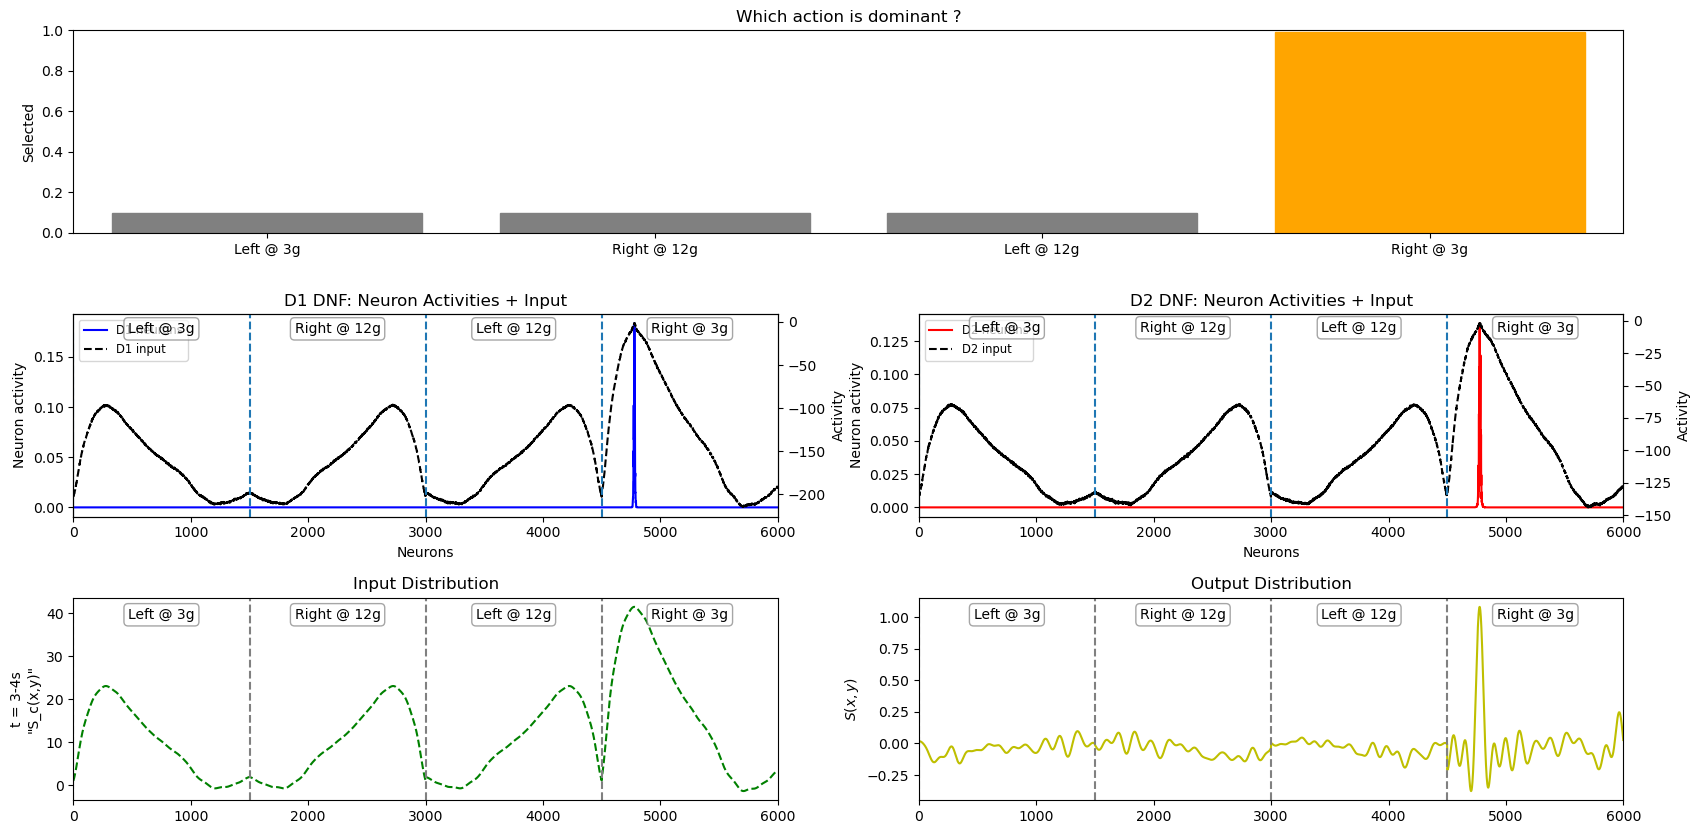

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.gridspec as gridspec

# ——————————————————————————————
# 1) build helper lists of indices
# ——————————————————————————————
time_intervals = int(len(time) / 1000)    # 4
# pick the last timestep in each 1 s window
frame_idxs = [(t+1)*1000 - 2 for t in range(time_intervals)]


# ——————————————————————————————
# 2) set up figure & axes with GridSpec
# ——————————————————————————————
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1], hspace=0.4)

ax_bar = fig.add_subplot(gs[0, :])
ax_d1  = fig.add_subplot(gs[1, 0])
ax_d2  = fig.add_subplot(gs[1, 1])
ax_in  = fig.add_subplot(gs[2, 0])
ax_out = fig.add_subplot(gs[2, 1])

# — Salience bar (top) —
ax_bar.set_title("Which action is dominant ?")
ax_bar.set_xlim(-0.5, n_actions_task-0.5)
ax_bar.set_ylim(0, 1)
ax_bar.set_xticks(range(n_actions_task))
ax_bar.set_xticklabels(action_labels)
ax_bar.set_ylabel("Selected")
bars = ax_bar.bar(range(n_actions_task), [0.1]*n_actions_task, color='gray')



# — Input / Output (middle) —
for ax, title in [(ax_in,"Input Distribution"), (ax_out,"Output Distribution")]:
    ax.set_xlim(0, domain_force.shape[0] * n_actions_task)
    ax.set_ylabel(r"$S(x,y)$")
    ax.set_title(title)
line_in,  = ax_in.plot([], [], 'g--', label='input')
line_out, = ax_out.plot([], [], 'y-',  label='output')

# — D1 panel with twin y-axis —
ax_d1_in = ax_d1.twinx()
ax_d1.set_title("D1 DNF: Neuron Activities + Input")
ax_d1.set_ylabel("Neuron activity")
ax_d1.set_xlabel("Neurons")
ax_d1_in.set_ylabel("D1 input",      color='k')
line_d1_act, = ax_d1.plot([], [], 'b-', label='D1 neurons')
line_d1_inp, = ax_d1_in.plot([], [], 'k--', label='D1 input')
h1, l1 = ax_d1.get_legend_handles_labels()
h2, l2 = ax_d1_in.get_legend_handles_labels()
ax_d1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize='small')

# — D2 panel with twin y-axis —
ax_d2_in = ax_d2.twinx()
ax_d2.set_title("D2 DNF: Neuron Activities + Input")
ax_d2.set_ylabel("Neuron activity")
ax_d2.set_xlabel("Neurons")
ax_d2_in.set_ylabel("D2 input", color='k')
line_d2_act, = ax_d2.plot([], [], 'r-', label='D2 neurons')
line_d2_inp, = ax_d2_in.plot([], [], 'k--', label='D2 input')
h1, l1 = ax_d2.get_legend_handles_labels()
h2, l2 = ax_d2_in.get_legend_handles_labels()
ax_d2.legend(h1 + h2, l1 + l2, loc='upper left', fontsize='small')

# Add vertical lines for action channel separation     
for i, ax in enumerate((ax_d1_in, ax_d2_in)):
    ax.set_ylim(auto=True)
    ax.set_xlim(0, domain_force.size * n_actions_task)
    ax.set_ylabel("Activity")
    # draw lines for the action channels 
    for n in range(n_actions_task):
        xpos = n * domain_force.shape[0]
        ax.axvline(xpos, linestyle='--')
        # compute the center between the this and the next section 
        if n < n_actions_task - 1:
            next_xpos = (n + 1) * domain_force.shape[0]
            x_text = (xpos + next_xpos)/2
        else:
            x_text = xpos + domain_force.shape[0]/2
        y_text = np.abs(ax.get_ylim()[1]) * 0.95 # 95% up teh y-axis
        ax.text(x_text, y_text, f"{action_labels[n]}", ha='center', va='top',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))
        
for ax in (ax_in, ax_out):
    ax.set_xlim(0, domain_force.shape[0] * n_actions_task)
    # draw vertical separators and labels
    for n, label in enumerate(action_labels):
        start  = n * domain_force.shape[0]
        ax.axvline(start, linestyle='--', color='gray')
        center = start + domain_force.shape[0] / 2
        ax.text(center, 0.95, label,
                transform=ax.get_xaxis_transform(),  # y in axes coords
                ha='center', va='top',
                fontsize='medium',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))
    
        
# ——————————————————————————————
# 3) init function
# ——————————————————————————————
def init():
    for ln in (line_in, line_out,
               line_d1_act, line_d1_inp,
               line_d2_act, line_d2_inp):
        ln.set_data([], [])
    for b in bars:
        b.set_height(0.1)
        b.set_color('gray')
    return (line_in, line_out,
            line_d1_act, line_d1_inp,
            line_d2_act, line_d2_inp,
            *bars)


# ——————————————————————————————
# 4) update function for each frame
# ——————————————————————————————
def update(frame):
    idx = frame_idxs[frame]
    # which channel wins _input_ salience here?
    ch  = out_salience[idx]
    
    # extract & decode input+output for that channel
    # matrix_in, matrix_out have shape (4,4,1500)
    Si = np.concatenate(matrix_in[idx // 1000])
    So = np.concatenate(matrix_out[idx // 1000])
    
    line_in.set_data(np.arange(domain_force.size * n_actions_task), Si)
    line_out.set_data(np.arange(domain_force.size * n_actions_task), So)
    ax_in .relim();    ax_in .autoscale_view()
    ax_out.relim();  ax_out.autoscale_view()
    
    # D1 & D2 neuron activities for that channel
    # — D1 neurons + input —
    d1a   = d1_neurons[idx]
    d1i   = d1_input[idx]
    xdom  = np.arange(domain_force.size * n_actions_task)
    line_d1_act.set_data(xdom, d1a)
    line_d1_inp.set_data(xdom, d1i)
    ax_d1 .relim();    ax_d1 .autoscale_view()
    ax_d1_in.relim();  ax_d1_in.autoscale_view()

    # — D2 neurons + input —
    d2a = d2_neurons[idx]
    d2i = d2_input[idx]
    line_d2_act.set_data(xdom, d2a)
    line_d2_inp.set_data(xdom, d2i)
    ax_d2 .relim();    ax_d2 .autoscale_view()
    ax_d2_in.relim();  ax_d2_in.autoscale_view()

    
    # update the salience bars
    sal = np.ones(n_actions) * 0.1
    sal[ch] = 0.99
    for b, s in zip(bars, sal):
        b.set_height(s)
        b.set_color('orange' if s>0.1 else 'gray')
    
    # update subtitles 
    ax_in.set_ylabel(f't = {frame}-{frame+1}s\n"S_c(x,y)"')

    return (line_in, line_out,
            line_d1_act, line_d1_inp,
            line_d2_act, line_d2_inp,
            *bars)
# ——————————————————————————————
# 5) run it!
# ——————————————————————————————
ani = FuncAnimation(fig, update, frames=time_intervals,
                    init_func=init, blit=True, repeat=True)
# ani.save('bg_dynamics.gif', dpi=80, fps=1)
ani.save('./figures/modified_park/dynamics.gif', dpi=80, fps=1)
plt.show()